In [1]:
import torch
import numpy as np

## Loading Data

In [4]:
import numpy as np
import math as py_math
from phi.flow import * 

def run_simulation(save_path="burgers_data.npy"):
    # 1. Setup Physical Parameters
    NU_TRUE = 0.01 / py_math.pi 
    DT = 0.01
    STEPS = 100
    
    # --- CORRECTION HERE ---
    # We do not create a 'Domain' object. 
    # We define the bounds and resolution as variables to pass later.
    BOUNDS = Box(x=(-1, 1))
    RESOLUTION = 128
    
    # 2. Initial Condition: u(x,0) = -sin(pi * x)
    # We pass x=128 (resolution) and bounds directly here.
    initial_state = CenteredGrid(
        values=lambda x: -math.sin(py_math.pi * x), 
        extrapolation=extrapolation.PERIODIC, 
        x=RESOLUTION,      # Define Resolution here
        bounds=BOUNDS      # Define Physical Bounds here
    )

    # 3. Simulation Loop
    u_history = [initial_state.values.numpy('x')]
    t_history = [0.0]
    
    u_current = initial_state
    
    print(f"Running PhiFlow Simulation (nu={NU_TRUE:.4f})...")
    
    for i in range(1, STEPS + 1):
        # Burgers Step
        u_adv = advect.mac_cormack(u_current, u_current, dt=DT)
        u_next = diffuse.explicit(u_adv, NU_TRUE, dt=DT)
        
        u_current = u_next
        
        # Store state
        u_history.append(u_current.values.numpy('x'))
        t_history.append(i * DT)

    # 4. Data Post-Processing (Same as before)
    # Get physical x coordinates from the grid
    x_coords = initial_state.points.vector[0].numpy('x') 
    
    t_array = np.array(t_history)
    u_array = np.array(u_history) 
    
    X_grid, T_grid = np.meshgrid(x_coords, t_array)
    
    data_dict = {
        "x": X_grid.flatten()[:, None].astype(np.float32),
        "t": T_grid.flatten()[:, None].astype(np.float32),
        "u": u_array.flatten()[:, None].astype(np.float32)
    }
    
    print(f"Simulation Complete. Data shape: {data_dict['x'].shape}")
    np.save(save_path, data_dict, allow_pickle=True)

    return data_dict

data_dict = run_simulation()

Running PhiFlow Simulation (nu=0.0032)...
Simulation Complete. Data shape: (12928, 1)


In [5]:
data_dict

{'x': array([[-0.9921875],
        [-0.9765625],
        [-0.9609375],
        ...,
        [ 0.9609375],
        [ 0.9765625],
        [ 0.9921875]], shape=(12928, 1), dtype=float32),
 't': array([[0.],
        [0.],
        [0.],
        ...,
        [1.],
        [1.],
        [1.]], shape=(12928, 1), dtype=float32),
 'u': array([[ 0.02454121],
        [ 0.07356445],
        [ 0.12241069],
        ...,
        [-0.02941972],
        [-0.01765222],
        [-0.00588416]], shape=(12928, 1), dtype=float32)}

## Defining and Training the Neural Net Model

Training on: mps
Dataset Loaded. Shape: torch.Size([12928, 1])
Starting optimization...
Epoch 0: Loss = 0.258608
Epoch 100: Loss = 0.000721
Epoch 200: Loss = 0.000119
Epoch 300: Loss = 0.000044
Epoch 400: Loss = 0.000032
Epoch 500: Loss = 0.000021
Epoch 600: Loss = 0.000018
Epoch 700: Loss = 0.000019
Epoch 800: Loss = 0.000013
Epoch 900: Loss = 0.000013
Epoch 1000: Loss = 0.000007
Epoch 1100: Loss = 0.000010
Epoch 1200: Loss = 0.000011
Epoch 1300: Loss = 0.000009
Epoch 1400: Loss = 0.000013
Epoch 1500: Loss = 0.000007
Epoch 1600: Loss = 0.000012
Epoch 1700: Loss = 0.000004
Epoch 1800: Loss = 0.000007
Epoch 1900: Loss = 0.000009
Training Complete.


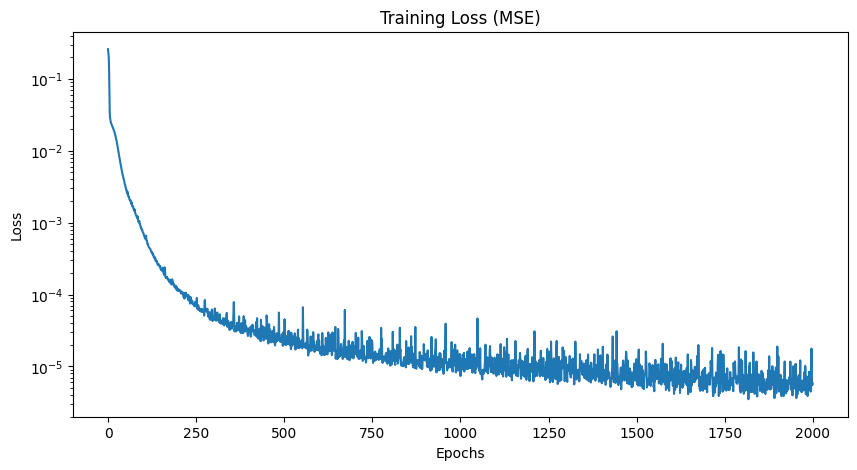

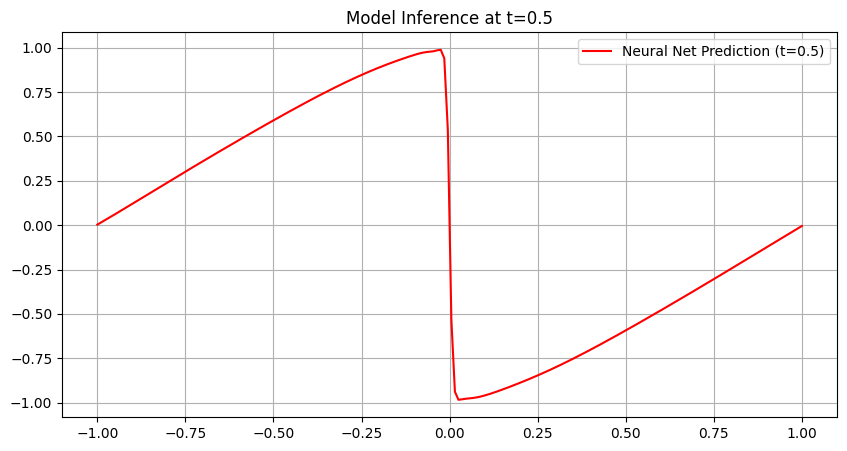

Model saved to burgers_model.pth


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. DEFINE THE NEURAL NETWORK
# ==========================================
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        # Input: 2 (x, t) -> Output: 1 (u)
        # We use Tanh because it is smooth (infinitely differentiable)
        self.net = nn.Sequential(
            nn.Linear(2, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1)
        )

    def forward(self, x, t):
        # Concatenate x and t to form the input vector [batch, 2]
        inputs = torch.cat([x, t], dim=1)
        return self.net(inputs)

# ==========================================
# 2. DEFINE THE DATASET LOADER
# ==========================================
class BurgersDataset(Dataset):
    def __init__(self, file_path="burgers_data.npy"):
        # Load the dictionary we saved earlier
        data = np.load(file_path, allow_pickle=True).item()
        
        self.x = torch.tensor(data['x'], dtype=torch.float32)
        self.t = torch.tensor(data['t'], dtype=torch.float32)
        self.u = torch.tensor(data['u'], dtype=torch.float32)
        
        print(f"Dataset Loaded. Shape: {self.x.shape}")

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.t[idx], self.u[idx]

# ==========================================
# 3. THE TRAINING PROCEDURE
# ==========================================
def train():
    # A. Setup
    device = torch.device("mps" if torch.mps.is_available() else "cpu")
    print(f"Training on: {device}")
    
    # Load Data
    dataset = BurgersDataset("burgers_data.npy")
    dataloader = DataLoader(dataset, batch_size=256, shuffle=True)
    
    # Initialize Model
    model = SimpleMLP().to(device)
    
    # Optimizer (Adam is standard for initial convergence)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    # Loss Function (Mean Squared Error)
    criterion = nn.MSELoss()
    
    epochs = 2000
    loss_history = []

    # B. Optimization Loop
    print("Starting optimization...")
    model.train()
    
    for epoch in range(epochs):
        epoch_loss = 0
        
        for batch_x, batch_t, batch_u in dataloader:
            # Move data to GPU if available
            batch_x = batch_x.to(device)
            batch_t = batch_t.to(device)
            batch_u = batch_u.to(device)
            
            # 1. Forward Pass
            # The model predicts u based on x and t
            u_prediction = model(batch_x, batch_t)
            
            # 2. Compute Loss
            # Compare prediction vs Ground Truth (from PhiFlow)
            loss = criterion(u_prediction, batch_u)
            
            # 3. Backward Pass (Gradient Descent)
            optimizer.zero_grad() # Clear old gradients
            loss.backward()       # Calculate new gradients
            optimizer.step()      # Update weights
            
            epoch_loss += loss.item()
        
        # Log average loss per epoch
        avg_loss = epoch_loss / len(dataloader)
        loss_history.append(avg_loss)
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Loss = {avg_loss:.6f}")

    print("Training Complete.")
    
    # ==========================================
    # 4. VISUALIZATION (Inference)
    # ==========================================
    # Let's visualize the result at t=0.5
    model.eval() # Set to evaluation mode
    
    # Create a test line for t=0.5
    test_x = torch.linspace(-1, 1, 200).view(-1, 1)
    test_t = torch.full((200, 1), 0.5) # Constant time t=0.5
    
    with torch.no_grad():
        prediction = model(test_x.to(device), test_t.to(device)).cpu()
    
    plt.figure(figsize=(10, 5))
    plt.plot(loss_history)
    plt.yscale('log')
    plt.title("Training Loss (MSE)")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(test_x.numpy(), prediction.numpy(), label="Neural Net Prediction (t=0.5)", color="red")
    plt.title("Model Inference at t=0.5")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Save the model for later use
    torch.save(model.state_dict(), "burgers_model.pth")
    print("Model saved to burgers_model.pth")


train()

## Testing / Visualization

Visualizing using: cpu
Model weights loaded successfully.


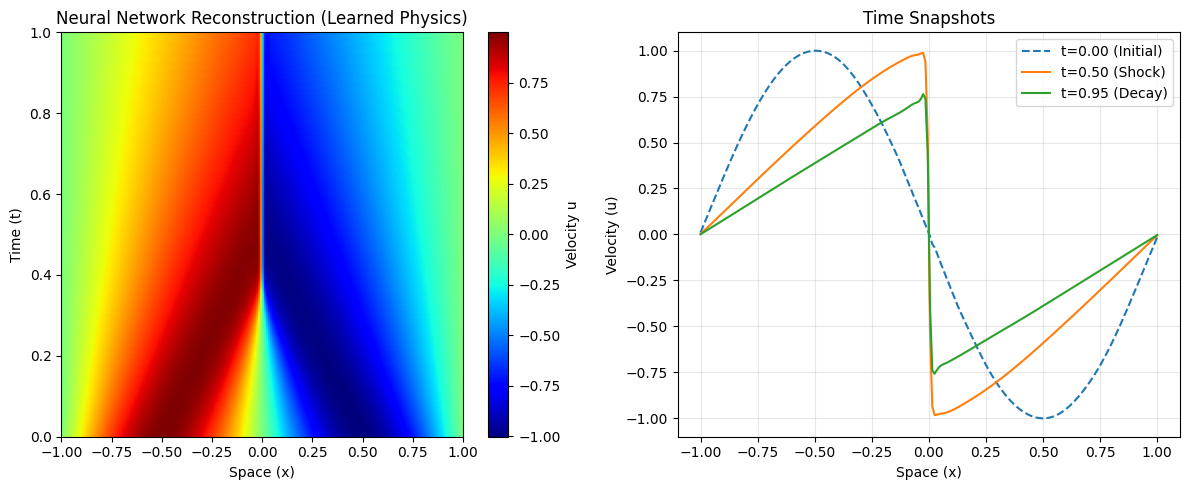

In [7]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. RE-DEFINE THE MODEL STRUCTURE
# ==========================================
# We must define the class again to load weights into it
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1)
        )

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        return self.net(inputs)

# ==========================================
# 2. GENERATE PREDICTION GRID
# ==========================================
def visualize():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Visualizing using: {device}")

    # Load Model
    model = SimpleMLP().to(device)
    try:
        model.load_state_dict(torch.load("burgers_model.pth"))
        print("Model weights loaded successfully.")
    except FileNotFoundError:
        print("Error: burgers_model.pth not found. Run training script first.")
        return

    model.eval() # Set to evaluation mode

    # Create a fine grid for visualization (finer than training if desired)
    # Resolution: 200 x 200 pixels
    x_np = np.linspace(-1, 1, 200)
    t_np = np.linspace(0, 1, 200)
    
    X_grid, T_grid = np.meshgrid(x_np, t_np)
    
    # Flatten for the network
    x_flat = X_grid.flatten()[:, None]
    t_flat = T_grid.flatten()[:, None]
    
    # Convert to Tensor
    x_tensor = torch.tensor(x_flat, dtype=torch.float32).to(device)
    t_tensor = torch.tensor(t_flat, dtype=torch.float32).to(device)
    
    # Inference
    with torch.no_grad():
        u_pred_flat = model(x_tensor, t_tensor).cpu().numpy()
        
    # Reshape back to 2D Grid for plotting
    U_pred_grid = u_pred_flat.reshape(200, 200)

    # ==========================================
    # 3. PLOT 1: SPACETIME HEATMAP
    # ==========================================
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(
        U_pred_grid,
        extent=[-1, 1, 0, 1], # x: -1 to 1, t: 0 to 1
        origin='lower',
        aspect='auto',
        cmap='jet'
    )
    plt.colorbar(label='Velocity u')
    plt.xlabel('Space (x)')
    plt.ylabel('Time (t)')
    plt.title('Neural Network Reconstruction (Learned Physics)')

    # ==========================================
    # 4. PLOT 2: SNAPSHOTS (SHOCK CAPTURE)
    # ==========================================
    # Extract rows corresponding to t=0.0, t=0.5, t=0.9
    # Indices in a 200-step grid: 0, 100, 180
    
    plt.subplot(1, 2, 2)
    plt.plot(x_np, U_pred_grid[0, :], label='t=0.00 (Initial)', linestyle='--')
    plt.plot(x_np, U_pred_grid[100, :], label='t=0.50 (Shock)')
    plt.plot(x_np, U_pred_grid[190, :], label='t=0.95 (Decay)')
    
    plt.xlabel('Space (x)')
    plt.ylabel('Velocity (u)')
    plt.title('Time Snapshots')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize()